# Instalando pacotes necessários

Utilizei a biblioteca python [Pymoo](https://pymoo.org/index.html) para a implementação dos algorítmos, devido à facilidade de criação/customização dos algorítmos/problemas utilizados.

Acabei utilizando o scikit-learn devido a implementação do KMeans, o qual foi utilizado para a hibridização dos algorítmos de ES/DE que serão mostrados posteriormente.

In [5]:
!pip install matplotlib numpy pymoo scikit-learn scikit-opt

# Instanciando as bibliotecas e datasets da Iris, Breast Cancer e Wine.

In [30]:
import copy

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris, load_breast_cancer, load_wine
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

from pymoo.algorithms.soo.nonconvex.es import ES
from pymoo.optimize import minimize
from pymoo.core.population import Population
from pymoo.core.problem import Problem
from pymoo.core.algorithm import Algorithm

from dataclasses import dataclass

from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.algorithms.soo.nonconvex.ga import FitnessSurvival
from pymoo.core.replacement import ImprovementReplacement

from time import time

iris = load_iris()
x_iris = iris.data       # características
y_iris = iris.target     # rótulos (apenas para avaliação)
x_iris_train, x_iris_test, y_iris_train, y_iris_test = train_test_split(
    x_iris, y_iris,
    test_size=0.1,
    stratify=y_iris,
)

# iris_min_3_cluster = 78.8514

breast = load_breast_cancer()
x_breast = breast.data
y_breast = breast.target
x_breast_train, x_breast_test, y_breast_train, y_breast_test = train_test_split(
    x_breast, y_breast,
    test_size=0.1,
    stratify=y_breast,
)

wine = load_wine()
x_wine = wine.data
y_wine = wine.target
x_wine_train, x_wine_test, y_wine_train, y_wine_test = train_test_split(
    x_wine, y_wine,
    test_size=0.1,
    stratify=y_wine
)
np.random.seed(1000) # Para facilmente ser reproduzível
seeds = np.random.randint(0, 2**32 - 1, size=7)

# Definições de Classes, Algorítmos do ES, Problemas (Problema de Clusterização), Funções (Fitness/KMeans Exploitation)



In [31]:

@dataclass
class FitnessHistory:
    iris : list
    breast: list
    wine: list
    iris_best_cen: list
    breast_best_cen: list
    wine_best_cen: list


def kmeans_explotation(population,data, cluster_n):
    for i, chromosome in enumerate(population):
        centroids = chromosome.reshape(cluster_n,data.shape[1])
        # https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
        km = KMeans(
            init=centroids,
            n_clusters=cluster_n,
            n_init=1,
            max_iter=1
        )

        km.fit(data)
        population[i] = km.cluster_centers_.flatten()


def fitness(chromosome, data, cluster_n):
    centroids = chromosome.reshape(cluster_n, data.shape[1])

    sse = 0.0

    for x in data:
        dist_cen = np.sum((centroids - x) ** 2, axis=1)
        sse += np.min(dist_cen) # Pega a menor distância dos centros

    return round(sse, 4) # 4 Casas decimais


class CustomES_Elitism(ES): # -> Convergiu prematuramente
    # https://pymoo.org/algorithms/soo/es.html
    def _advance(self, infills=None, **kwargs):

        # Pais + filhos -> Lib seleciona somente os filhos (sem elitismo)
        infills = Population.merge(self.pop, infills)

        # Seleciona os μ melhores
        self.pop = self.survival.do(
            self.problem,
            infills,
            n_survive=self.pop_size
        )

class CustomES_Elitism_Kmeans(ES):
    # https://pymoo.org/algorithms/soo/es.html
    def _advance(self, infills=None, **kwargs):
        infills = Population.merge(self.pop, infills)
        pop = copy.deepcopy(infills.get("X"))
        kmeans_explotation(pop,self.problem.dataset_data,self.problem.n_clusters)
        infills.set("X", pop)

        self.evaluator.eval( # Utilizado para salvar histórico da fitness nova
            self.problem,
            infills
        )

        # Seleciona os μ melhores
        self.pop = self.survival.do(
            self.problem,
            infills,
            n_survive=self.pop_size
        )


class CustomES_Kmeans(ES):

    def _advance(self, infills=None, **kwargs):
        pop = copy.deepcopy(infills.get("X"))
        kmeans_explotation(pop,self.problem.dataset_data,self.problem.n_clusters)
        infills.set("X", pop)

        self.evaluator.eval(
            self.problem,
            infills
        )

        if len(infills) < self.pop_size:
            infills = Population.merge(infills, self.pop)

        self.pop = self.survival.do(self.problem, infills, n_survive=self.pop_size)


class ClusterProblem(Problem):
    def __init__(self,x,y):
        self.n_clusters = np.unique(y).size
        self.dataset_data = x
        # Já utiliza pega max/min de cada coluna, no "xl" e "xu"
        super().__init__(
            n_var=self.n_clusters * self.dataset_data.shape[1],
            n_obj=1,
            xl=np.tile(x.min(axis=0), self.n_clusters),
            xu=np.tile(x.max(axis=0), self.n_clusters),
        )

    def _evaluate(self, x, out, *args, **kwargs):
        fitness_vec = np.zeros(len(x))
        for i, chromosome in enumerate(x):
            fitness_vec[i] = fitness(chromosome,self.dataset_data,self.n_clusters)

        out["F"] = fitness_vec



# População Inicial e Fitness

Todos os algoritmos avaliados neste trabalho utilizam como função de fitness o Sum of Squared Errors (SSE), definido como:



$\mathrm{SSE} = \sum_{i=1}^{N} \left\| x_i - c_{k(i)} \right\|^2$


em que $x_i$ representa cada ponto de dados, $c_{k(i)}$ é o centróide do cluster ao qual o ponto $x_i$ está associado, e $N$ é o número total de amostras. O objetivo da otimização consiste em minimizar o SSE, buscando agrupamentos mais compactos e bem separados.

Em relação à inicialização da população, todos os algoritmos, com exceção do algoritmo de Differential Evolution (DE) proposto no artigo de referência, utilizam inicialização aleatória da população no espaço de busca. Essa estratégia não incorpora conhecimento prévio sobre a estrutura dos dados.

Por outro lado, o DE do artigo utiliza uma estratégia de inicialização baseada no algoritmo de KMeans, conforme descrito na metodologia original.

# Testando o ES mais robusto

Abaixo segue o teste de quatro variações de algorítmos de ES :

- ES(λ,μ) : Algorítmo Padrão do ES que somente propaga os melhores filhos.

- ES(λ,μ) + KMeans : A cada Iteração do algorítmo também é usado uma iteração do KMeans para cada filho gerado, e depois é feita a seleção.

- ES(λ+μ) : Algorítmo Padrão do ES que propaga os melhores indíviduos (pais incluso).  

- ES(λ+μ) + KMeans :  A cada Iteração do algorítmo também é usado uma iteração do KMeans para cada indivíduo, e depois é feita a seleção.

Foi escolhido como critério de parada 80 iterações em cada dataset (Iris, Breast Cancer e Wine), devido a demora da execução de cada algorítmo. Além disso, a avaliação de cada algorítmo é repetida 7 vezes (cada repetição com uma seed diferente, e todos os algorítmos usam a mesma seed) para adquirir a média e o melhor resultado de cada algorítmo em cada dataset, avaliando assim a sua robustez. A melhor variação de ES será posteriormente comparada com a melhor variação do algortímo de DE.

In [32]:
def RunPymooProblem(
    algorithm,
    problem : ClusterProblem,
    termination : tuple,
    seed: int | None,
    save_history : bool = True,
):
    if not seed:
        seed = 100
    res = minimize(
        problem=problem,
        algorithm=algorithm,
        termination=termination,
        seed=seed,
        verbose=False,
        save_history=save_history
    )
    return res


def ESClusterizationProblems(
    seed: int | None,
    es_class,
    max_it: int = 80,
):
    iris_problem = ClusterProblem(
        x=x_iris_train,
        y=y_iris_train,
    )
    breast_problem = ClusterProblem(
        x=x_breast_train,
        y=y_breast_train,
    )
    wine_problem = ClusterProblem(
        x=x_wine_train,
        y=y_wine_train,
    )
    iris = RunPymooProblem(
        algorithm=es_class(
            pop_size=30,
            rule=1/7, # pais/filhos = sigma/lambda = 1/7
            gamma=None,
        ),
        problem=iris_problem,
        termination=("n_iter", max_it), # Desisti, não achei o valor ideal de SSE do Breast/Wine, então não é justo...
        # termination=TerminationCollection(
        #     MaximumGenerationTermination(max_it),
        #     MinimumFunctionValueTermination(iris_min_3_cluster)
        # ),
        seed=seed,
    )
    breast = RunPymooProblem(
        algorithm=es_class(
            pop_size=30,
            rule=1/7, # pais/filhos = sigma/lambda = 1/7
            gamma=None,
        ),
        problem=breast_problem,
        termination=("n_iter", max_it),
        seed=seed,
    )
    wine = RunPymooProblem(
        algorithm=es_class(
            pop_size=30,
            rule=1/7, # pais/filhos = sigma/lambda = 1/7
            gamma=None,
        ),
        problem=wine_problem,
        termination=("n_iter", max_it),
        seed=seed,
    )


    return FitnessHistory(
        iris=iris.history,
        breast=breast.history,
        wine=wine.history,
        iris_best_cen=iris.X,
        breast_best_cen=breast.X,
        wine_best_cen=wine.X,
    )


def plot_results_table(fitness_dict, save_path=None):
    data = []
    for algorithm, histories in fitness_dict.items():

        if len(histories) == 0:
            continue

        # percorre iris, breast e wine separadamente
        for dataset_name in ["iris", "breast", "wine"]:

            best_runs = []
            iter_runs = []
            # print(histories)
            for fitness_history in histories:

                dataset = getattr(fitness_history, dataset_name)

                if dataset is None:
                    continue

                best = min(run.opt.get("F")[0][0] for run in dataset)
                best_runs.append(best)
                iter_runs.append(len(dataset))

            if len(best_runs) == 0:
                continue

            data.append([
                algorithm,
                dataset_name,
                # f"{np.mean(iter_runs):.1f}",
                f"{np.min(best_runs):.4f}",
                f"{np.mean(best_runs):.4f}",
            ])

    fig, ax = plt.subplots(figsize=(10, 0.6 * len(data) + 1.5))
    ax.axis("off")

    table = ax.table(
        cellText=data,
        colLabels=[
            "Algoritmo",
            "Dataset",
            # "Iterações médias",
            "Melhor resultado",
            "Resultado médio"
        ],
        loc="center",
        cellLoc="center"
    )

    # Colocar os melhores em negrito
    best_per_dataset = {}

    for row in data:
        dataset = row[1]
        best = float(row[2])
        mean = float(row[3])

        if dataset not in best_per_dataset:
            best_per_dataset[dataset] = [best, mean]
        else:
            best_per_dataset[dataset][0] = min(best_per_dataset[dataset][0], best)
            best_per_dataset[dataset][1] = min(best_per_dataset[dataset][1], mean)

    for i, row in enumerate(data, start=1):

        dataset = row[1]
        best = float(row[2])
        mean = float(row[3])

        if best == best_per_dataset[dataset][0]:
            table[(i, 2)].get_text().set_fontweight("bold")

        if mean == best_per_dataset[dataset][1]:
            table[(i, 3)].get_text().set_fontweight("bold")


    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_fitness_history(fitness_dict, dataset_name="iris",save_path=None):
    plt.figure(figsize=(10, 5))

    for alg, histories in fitness_dict.items():

        all_curves = []

        for fitness_history in histories:
            dataset = getattr(fitness_history, dataset_name)

            if dataset is None:
                continue

            curve = []

            for run in dataset:
                f = run.opt.get("F")[0][0]
                curve.append(f)

            all_curves.append(curve)

        if len(all_curves) == 0:
            continue

        # pad para mesmo tamanho
        # repete o ultimo valor para fazer a média
        max_len = max(len(c) for c in all_curves)

        padded = np.array([
            np.pad(c, (0, max_len - len(c)), mode="edge")
            for c in all_curves
        ])

        mean_curve = np.mean(padded, axis=0)

        plt.plot(mean_curve, label=alg)

    plt.title(f"Histórico Fitness Média - {dataset_name}")
    plt.xlabel("Iteração")
    plt.ylabel("Fitness Média")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def evaluate_centroids(x_test, centroids,n_clusters):
    centroids = centroids.reshape(n_clusters, x_test.shape[1])
    distances = np.linalg.norm(
        x_test[:, None, :] - centroids[None, :, :],
        axis=2
    )

    labels = np.argmin(distances, axis=1)

    sse = np.sum((x_test - centroids[labels]) ** 2)

    return sse


def evaluate_test_sets(fitness_dict):
    datasets = {
        "iris": (
            x_iris_test,
            y_iris_test,
            len(np.unique(y_iris_train))
        ),
        "breast": (
            x_breast_test,
            y_breast_test,
            len(np.unique(y_breast_train))
        ),
        "wine": (
            x_wine_test,
            y_wine_test,
            len(np.unique(y_wine_train))
        ),
    }

    for algorithm, runs in fitness_dict.items():

        print(f"\n=== {algorithm} ===")

        for dataset_name, (x_test, y_test, n_clusters) in datasets.items():

            scores = []

            for run in runs:

                centroids = getattr(run, f"{dataset_name}_best_cen")

                if centroids is None:
                    continue

                score = evaluate_centroids(
                    x_test,
                    centroids,
                    n_clusters
                )

                scores.append(score)

            if scores:
                print(
                    f"{dataset_name:<8}"
                    f" Média  (SSE) = {np.mean(scores):.4f}"
                    f" Melhor (SSE) = {np.max(scores):.4f}"
                    f" Desvio (SSE) = {np.std(scores):.4f}"
                )

Running Seed 1 : 2807145907


/home/rafael/comp_natural/trab1/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/rafael/comp_natural/trab1/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Finished Seed 1: 2807145907, Runtime : 236.76s
Running Seed 2 : 882709079
Finished Seed 2: 882709079, Runtime : 232.88s
Running Seed 3 : 493951047
Finished Seed 3: 493951047, Runtime : 232.57s
Running Seed 4 : 2621574848


/home/rafael/comp_natural/trab1/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Finished Seed 4: 2621574848, Runtime : 232.88s
Running Seed 5 : 4081433851
Finished Seed 5: 4081433851, Runtime : 231.72s
Running Seed 6 : 44058974
Finished Seed 6: 44058974, Runtime : 232.08s
Running Seed 7 : 2070996316


/home/rafael/comp_natural/trab1/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/rafael/comp_natural/trab1/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Finished Seed 7: 2070996316, Runtime : 232.10s


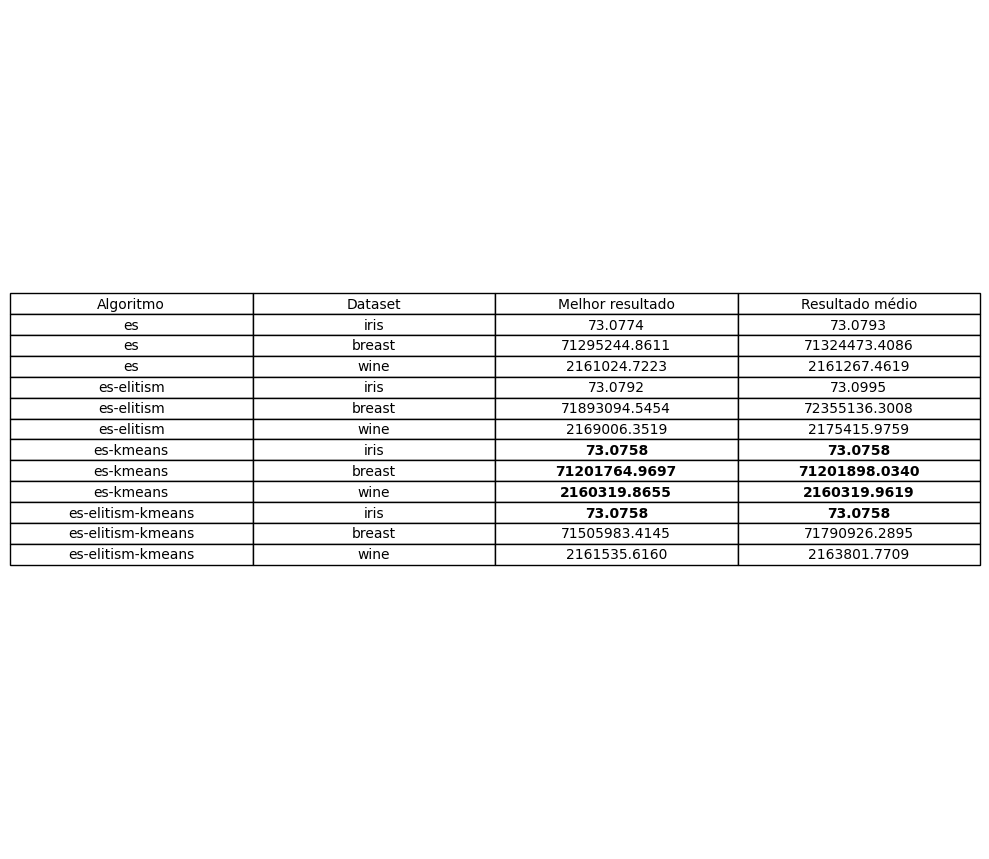

In [33]:
fitness_dict = {}
fitness_dict["es"] = []
fitness_dict["es-elitism"] = []
fitness_dict["es-kmeans"] = []
fitness_dict["es-elitism-kmeans"] = []
for i,seed in enumerate(seeds):
    it_start_time = time()
    print(f"Running Seed {i+1} : {seed}")
    fitness_es = ESClusterizationProblems(seed=seed,es_class=ES) # Já utiliza FloatRandomSampling() -> Não é necessário a inicalização manual dos indivíduos
    fitness_es_kmeans = ESClusterizationProblems(seed=seed,es_class=CustomES_Kmeans)
    fitness_es_elitism = ESClusterizationProblems(seed=seed,es_class=CustomES_Elitism)
    fitness_es_elistism_kmeans = ESClusterizationProblems(seed=seed,es_class=CustomES_Elitism_Kmeans)

    fitness_dict["es"].append(fitness_es)
    fitness_dict["es-kmeans"].append(fitness_es_kmeans)
    fitness_dict["es-elitism"].append(fitness_es_elitism)
    fitness_dict["es-elitism-kmeans"].append(fitness_es_elistism_kmeans)
    print(f"Finished Seed {i+1}: {seed}, Runtime : {time()-it_start_time:.2f}s")
plot_results_table(fitness_dict,"es_results.png")

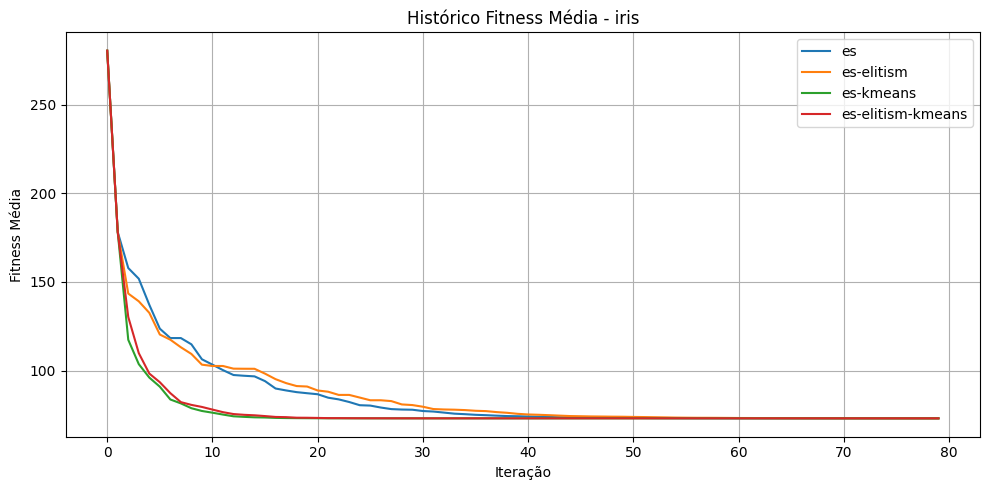

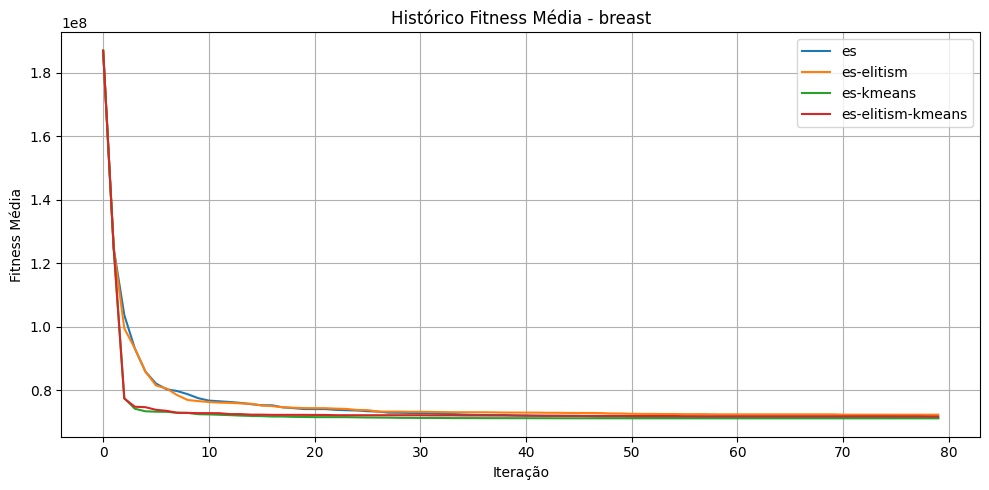

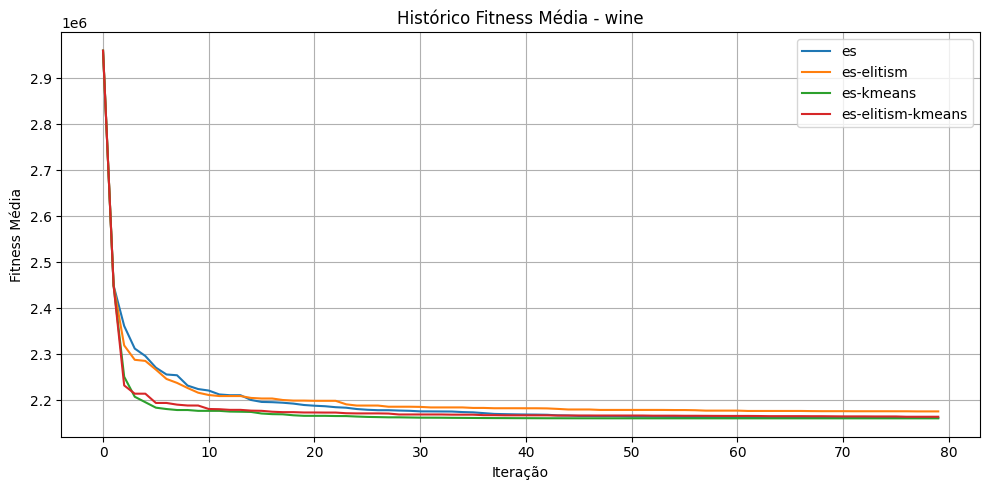

In [34]:
plot_fitness_history(fitness_dict, dataset_name="iris",save_path="es_iris_graph.png")
plot_fitness_history(fitness_dict, dataset_name="breast",save_path="es_breast_graph.png")
plot_fitness_history(fitness_dict, dataset_name="wine",save_path="es_wine_graph.png")

In [35]:
# print(fitness_dict["es"][0].iris_best_cen)
evaluate_test_sets(fitness_dict)


=== es ===
iris     Média  (SSE) = 5.8695 Melhor (SSE) = 5.8900 Desvio (SSE) = 0.0104
breast   Média  (SSE) = 6769096.8699 Melhor (SSE) = 6782067.4837 Desvio (SSE) = 7549.9464
wine     Média  (SSE) = 234656.5652 Melhor (SSE) = 236478.5266 Desvio (SSE) = 1324.9168

=== es-elitism ===
iris     Média  (SSE) = 5.8625 Melhor (SSE) = 5.9187 Desvio (SSE) = 0.0301
breast   Média  (SSE) = 6834866.7628 Melhor (SSE) = 6977267.1284 Desvio (SSE) = 84504.4955
wine     Média  (SSE) = 230755.4740 Melhor (SSE) = 243110.7913 Desvio (SSE) = 12016.1538

=== es-kmeans ===
iris     Média  (SSE) = 5.8635 Melhor (SSE) = 5.8635 Desvio (SSE) = 0.0000
breast   Média  (SSE) = 6759673.7028 Melhor (SSE) = 6759673.7028 Desvio (SSE) = 0.0000
wine     Média  (SSE) = 234536.1378 Melhor (SSE) = 234536.1378 Desvio (SSE) = 0.0000

=== es-elitism-kmeans ===
iris     Média  (SSE) = 5.8635 Melhor (SSE) = 5.8635 Desvio (SSE) = 0.0000
breast   Média  (SSE) = 6759673.7028 Melhor (SSE) = 6759673.7028 Desvio (SSE) = 0.0000
wine 

# Resultado ES

Como é possível observar, o ES(λ,μ)+KMeans foi o que melhor performou, o que pode ser explicado pela exploração do espaço de busca feita pelo ES e a intensificação deste espaço feita pela KMeans (exploration and exploitation).

O ES(λ+μ), devido ao elitismo (memória + intensificação) é um algorítmo que explora menos o espaço de busca, podendo causar problemas como convergência prematura (o que pode ter sido o caso do algorítmo acima).

A melhora ES(λ+μ)+KMeans em relação a sua versão sem KMeans pode ser justificada pelo fato de que o elitismo tem um fator de intensificação, mas ele é apenas aplicado para alguns indivíduos que sofrem crossover com os elites, o KMeans promove a intensificação do espaço de busca para todos os indivíduos, ou seja, ES(λ+μ) aumenta a fitness de alguns indivíduos (e possuí memória do melhor) e ES(λ+μ)+KMeans aumenta a fitness de todos os indivíduos (e possuí memória do melhor).

O ES(λ,μ) era esperado ter um pior resultado, devido a ter somente a característica de exploração global, uma vez que não há memória nem intensificação do espaço de busca. O desempenho do ES(λ,μ) ser melhor que o ES(λ+μ) (e sua versão com KMeans) é justificado devido a convergência prematura do ES(λ+μ) e também pelo fato de ter poucas iterações, ou seja, o resultado do ES(λ,μ) ser melhor pode ser devido a "sorte" para as seeds utilizadas.

# Definições de Algorítmos do DE

In [36]:
class CustomDE_Kmeans(DE):
    def _advance(self, infills=None, **kwargs):
        assert infills is not None, "This algorithms uses the AskAndTell interface thus infills must to be provided."

        pop = copy.deepcopy(infills.get("X"))
        kmeans_explotation(pop,self.problem.dataset_data,self.problem.n_clusters)
        infills.set("X", pop)

        self.evaluator.eval(
            self.problem,
            infills
        )

        # get the indices where each offspring is originating from
        pop_i = infills.get("index")
        # replace the individuals with the corresponding parents from the mating
        self.pop[pop_i] = ImprovementReplacement().do(self.problem, self.pop[pop_i], infills)

        # update the information regarding the current population
        FitnessSurvival().do(self.problem, self.pop, return_indices=True)


class DEPaper(Algorithm):

    def __init__(self,
                 CR,
                 pop_size=30,
                 tau=0.1,
                 L=0.05,
                 U=0.35,
                 Fmin=0.0,
                 Fmax=1.0,
                 **kwargs):

        super().__init__(**kwargs)

        self.pop_size = pop_size
        self.tau = tau
        self.L = L
        self.U = U
        self.Fmin = Fmin
        self.Fmax = Fmax
        if CR is None:
            raise ValueError("DEPaper needs a CR Value")
        self.CR = CR
        self.D = int(2/self.CR)


    def _initialize_infill(self):
        X = self._initialize_population()

        self.pop = Population.new(X=X)

        Fvec = np.random.uniform(
            self.Fmin,
            self.Fmax,
            self.pop_size
        )

        self.pop.set("Fvec", Fvec) # Vetor de F auto-adaptativos

        self.evaluator.eval(self.problem, self.pop)

        return self.pop


    def _initialize_advance(self, infills=None, **kwargs):
        self.pop = infills
        self.evaluator.eval(self.problem, self.pop)


    def _initialize_population(self):

        pop = np.zeros((self.pop_size, self.D))

        for i in range(self.pop_size):

            pop[i] = self._initialize_individual()

        return pop


    def _initialize_individual(self, t_kmeans=20):

        rng = np.random.default_rng(self.random_state)
        n_samples = self.problem.dataset_data.shape[0]

        # primeiro centróide aleatório escolhido dos dados
        idx = rng.integers(0, n_samples)
        centroids = [self.problem.dataset_data[idx]]

        # escolher os centroides demais
        for _ in range(1, self.problem.n_clusters):
            # amostra t pontos aleatórios (sem replacement)
            candidates_idx = rng.choice(n_samples, size=min(t_kmeans, n_samples), replace=False)
            candidates = self.problem.dataset_data[candidates_idx]

            # calcula distância mínima de cada candidato até centróides existentes
            dists = []
            for x in candidates:
                min_dist = np.min([np.linalg.norm(x - c) for c in centroids])
                dists.append(min_dist)

            # pega o mais distante
            best = candidates[np.argmax(dists)]
            centroids.append(best)

        return np.array(centroids).flatten()


    def _adapt_F(self):

        Fvec = self.pop.get("Fvec").copy()

        mask = np.random.rand(len(Fvec)) < self.tau

        Fvec[mask] = self.L + np.random.rand(np.sum(mask)) * (self.U - self.L)

        self.pop.set("Fvec", Fvec)


    def _mutation(self):

        X = self.pop.get("X")
        Fvec = self.pop.get("Fvec")

        mutant = np.empty_like(X)

        for i in range(self.pop_size):

            idx = np.arange(self.pop_size)

            idx = idx[idx != i]

            r1, r2, r3 = np.random.choice(
                idx,
                3,
                replace=False
            )

            mutant[i] = (
                X[r1]
                + Fvec[i] * (X[r2] - X[r3])
            )

        return mutant


    def _crossover(self, mutant):

        offspring = self.pop.get("X").copy()

        for i in range(self.pop_size):

            drand = np.random.randint(self.D)

            for j in range(self.D):

                if np.random.rand() <= self.CR or j == drand:

                    offspring[i, j] = mutant[i, j]

        return offspring


    def _kmeans_exploitation(self,population):
        for i, chromosome in enumerate(population):
            centroids = chromosome.reshape(self.problem.n_clusters,self.problem.dataset_data.shape[1])
            # https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
            km = KMeans(
                init=centroids,
                n_clusters=self.problem.n_clusters,
                n_init=1,
                max_iter=1,
                tol=1e-4
            )

            km.fit(self.problem.dataset_data)
            population[i] = km.cluster_centers_.flatten()
        return np.array(population)


    def _selection(self, temp_offspring):

        off = Population.new(X=temp_offspring)
        self.evaluator.eval(self.problem, off)

        off_X = off.get("X").copy()
        off_X = self._kmeans_exploitation(off_X)

        off.set("X", off_X)
        self.evaluator.eval(self.problem, off)

        # Atualizo se o indivíduo da população temporária for melhor que a versão não mutada+crossover
        X = self.pop.get("X")
        F = self.pop.get("F")
        X_off = off.get("X")
        F_off = off.get("F")

        F = np.array(F)
        F_off = np.array(F_off)

        replace = F_off[:, 0] < F[:, 0]

        X[replace] = X_off[replace]
        F[replace] = F_off[replace]


        # atualiza indivíduos e fitness
        self.pop.set("X", X)
        self.pop.set("F", F)


    def _advance(self, infills=None, **kwargs):

        self._adapt_F()

        mutant = self._mutation()
        temp_offspring = self._crossover(mutant)
        self._selection(temp_offspring)

        # reavaliar população atual
        self.evaluator.eval(self.problem, self.pop)


def DEClusterizationProblems(
    de_class,
    max_it: int = 80,
    seed: int | None = None,
):
    #https://pymoo.org/algorithms/soo/de.html
    iris_problem = ClusterProblem(
        x=x_iris_train,
        y=y_iris_train,
    )
    breast_problem = ClusterProblem(
        x=x_breast_train,
        y=y_breast_train,
    )
    wine_problem = ClusterProblem(
        x=x_wine_train,
        y=y_wine_train,
    )
    iris = RunPymooProblem(
        algorithm=de_class(
            variant="DE/best/1/bin",
            pop_size=200,
            CR=2.0/float((np.unique(y_iris).size * x_iris.shape[1])),
            F=0.3,
        ),
        problem=iris_problem,
        termination=("n_iter", max_it),
        seed=seed,
    )
    breast = RunPymooProblem(
        algorithm=de_class(
            variant="DE/best/1/bin",
            pop_size=200,
            CR=2.0/float((np.unique(y_breast).size * x_breast.shape[1])),
            F=0.3,
        ),
        problem=breast_problem,
        termination=("n_iter", max_it),
        seed=seed,
    )
    wine = RunPymooProblem(
        algorithm=de_class(
            variant="DE/best/1/bin",
            pop_size=200,
            CR=2.0/float((np.unique(y_wine).size * x_wine.shape[1])),
            F=0.3,
        ),
        problem=wine_problem,
        termination=("n_iter", max_it),
        seed=seed,
    )


    return FitnessHistory(
        iris=iris.history,
        breast=breast.history,
        wine=wine.history,
        iris_best_cen=iris.X,
        breast_best_cen=breast.X,
        wine_best_cen=wine.X,
    )


# Testando o DE mais robusto

Abaixo segue o teste de três variações de algorítmos do DE :

- DE : Algorítmo Padrão do DE.

- DE + KMeans : A cada Iteração do algorítmo também é usado uma iteração do KMeans para todos os indívudos, e depois é feita a seleção.

- DE Paper : DE utilizado no artigo "A clustering
method combining differential evolution with the K-means algorithm".  

Foi escolhido como critério de parada 80 iterações em cada dataset (Iris, Breast Cancer e Wine), devido a demora da execução de cada algorítmo. Além disso, a avaliação de cada algorítmo é repetida 7 vezes (cada repetição com uma seed diferente, e todos os algorítmos usam a mesma seed) para adquirir a média e o melhor resultado de cada algorítmo em cada dataset, avaliando assim a sua robustez. A melhor variação de DE será posteriormente comparada com a melhor variação do algortímo de ES.


Running Seed 1 : 2807145907
Finished Seed 1: 2807145907, Runtime : 174.28s
Running Seed 2 : 882709079
Finished Seed 2: 882709079, Runtime : 173.61s
Running Seed 3 : 493951047


/home/rafael/comp_natural/trab1/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Finished Seed 3: 493951047, Runtime : 170.23s
Running Seed 4 : 2621574848
Finished Seed 4: 2621574848, Runtime : 173.62s
Running Seed 5 : 4081433851


/home/rafael/comp_natural/trab1/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Finished Seed 5: 4081433851, Runtime : 173.70s
Running Seed 6 : 44058974
Finished Seed 6: 44058974, Runtime : 171.56s
Running Seed 7 : 2070996316


/home/rafael/comp_natural/trab1/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Finished Seed 7: 2070996316, Runtime : 171.52s


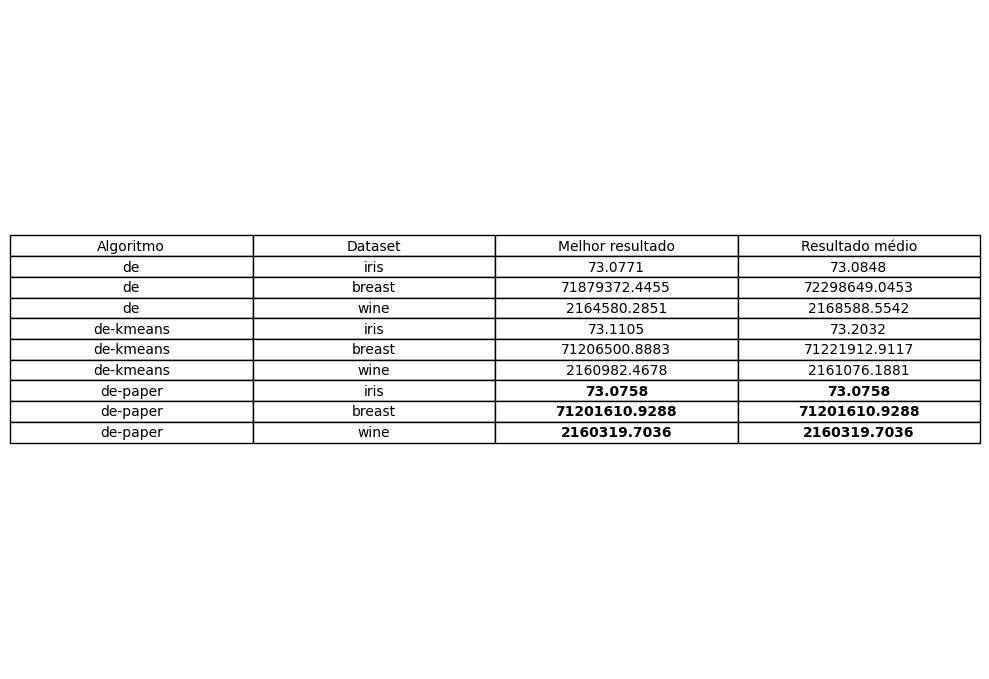

In [37]:
fitness_de_dict = {}
fitness_de_dict["de"] = []
fitness_de_dict["de-kmeans"] = []
fitness_de_dict["de-paper"] = []
for i,seed in enumerate(seeds):
    it_start_time = time()
    print(f"Running Seed {i+1} : {seed}")
    fitness_de = DEClusterizationProblems(seed=seed, de_class=DE)
    fitness_de_kmeans = DEClusterizationProblems(seed=seed, de_class=CustomDE_Kmeans)
    fitness_de_paper = DEClusterizationProblems(seed=seed,de_class=DEPaper)

    fitness_de_dict["de"].append(fitness_de)
    fitness_de_dict["de-kmeans"].append(fitness_de_kmeans)
    fitness_de_dict["de-paper"].append(fitness_de_paper)
    print(f"Finished Seed {i+1}: {seed}, Runtime : {time()-it_start_time:.2f}s")
plot_results_table(fitness_de_dict,save_path="de_results.png")

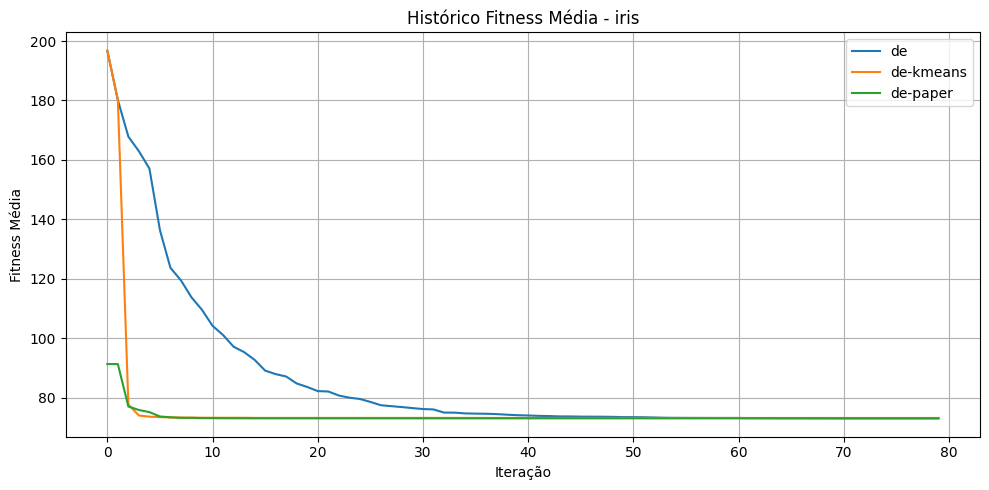

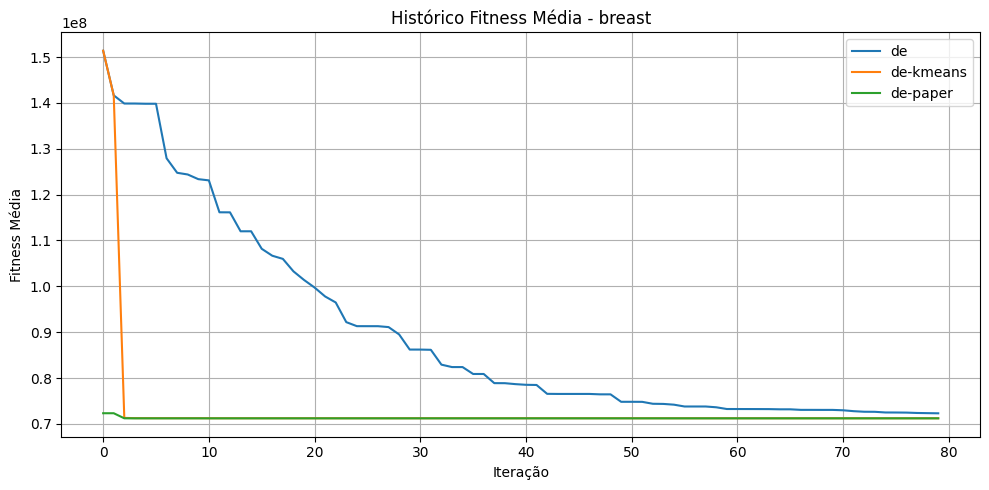

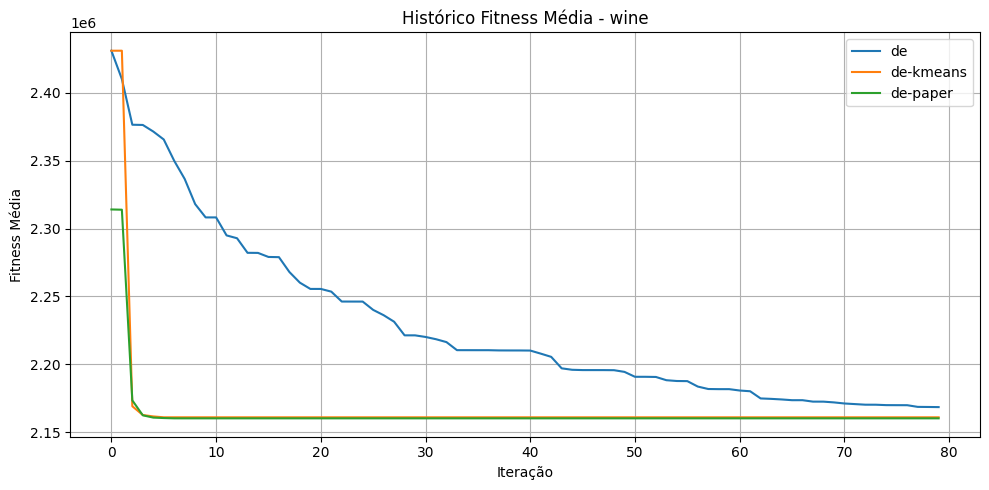

In [38]:
plot_fitness_history(fitness_de_dict, dataset_name="iris",save_path="de_iris_graph.png")
plot_fitness_history(fitness_de_dict, dataset_name="breast",save_path="de_breast_graph.png")
plot_fitness_history(fitness_de_dict, dataset_name="wine",save_path="de_wine_graph.png")

In [39]:
evaluate_test_sets(fitness_de_dict)


=== de ===
iris     Média  (SSE) = 5.8684 Melhor (SSE) = 5.8959 Desvio (SSE) = 0.0150
breast   Média  (SSE) = 6892259.1577 Melhor (SSE) = 7020310.1773 Desvio (SSE) = 87403.6671
wine     Média  (SSE) = 229587.2680 Melhor (SSE) = 243003.2696 Desvio (SSE) = 8137.2510

=== de-kmeans ===
iris     Média  (SSE) = 5.8461 Melhor (SSE) = 5.8635 Desvio (SSE) = 0.0200
breast   Média  (SSE) = 6759673.7028 Melhor (SSE) = 6759673.7028 Desvio (SSE) = 0.0000
wine     Média  (SSE) = 234536.1378 Melhor (SSE) = 234536.1378 Desvio (SSE) = 0.0000

=== de-paper ===
iris     Média  (SSE) = 5.8635 Melhor (SSE) = 5.8635 Desvio (SSE) = 0.0000
breast   Média  (SSE) = 6759673.7028 Melhor (SSE) = 6759673.7028 Desvio (SSE) = 0.0000
wine     Média  (SSE) = 234536.1378 Melhor (SSE) = 234536.1378 Desvio (SSE) = 0.0000


# Resultado DE

Como é possível observar, o DE aplicado no artigo foi o que melhor performou, uma vez que a exploração do espaço de busca feita pelo DE é auto-adaptativa, conservando os melhores pares indivíduo+fator de amplificação, e a intensificação do espaço de busca é agressiva, já que o KMeans é utilizado até a sua convergência a cada iteração do algorítmo.

A hibridização DE + KMeans não conseguiu superar os melhores resultados absolutos do DE puro, contudo, em média, atingiu melhores ótimos locais nos datasets diferentes do Iris. Isso pode ser explicado pela melhora da aptidão de todos os indivíduos de maneira mais incisiva do que no DE clássico. Por outro lado, o desempenho inferior no dataset Iris indica que essa abordagem agressiva de busca local pode ter induzido o algoritmo a uma convergência prematura em um espaço de busca menor.



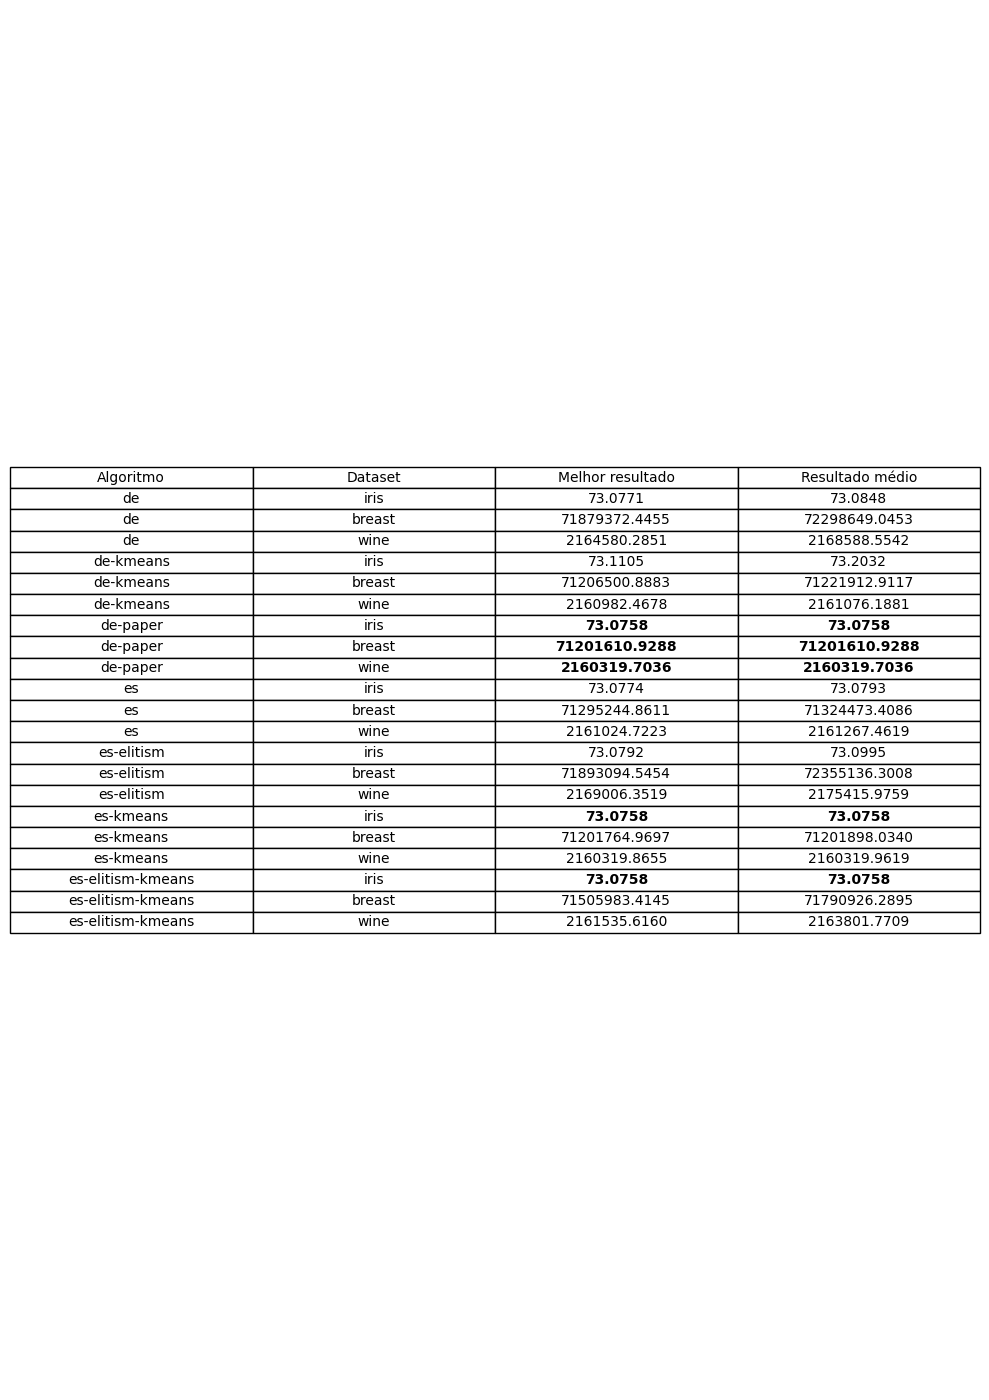

In [40]:
full_fitness_dict = {}
full_fitness_dict.update(fitness_de_dict)
full_fitness_dict.update(fitness_dict)
plot_results_table(full_fitness_dict,save_path="es_de_results.png")
# Memoria estorou na outra iteração, vou apagar com del (GC)
del fitness_dict
del fitness_de_dict

# Resultado Preliminar Geral

Como ilustrado na tabela acima, o algorítmo de DE aplicado no artigo é o que obteve melhores resultados, porém o ES(λ,μ)+KMeans obteve uma performance igual para o dataset do Iris, e parecida para os demais. Devido a esse fato, será testado qual algoritmo converge mais rapidamente (baseado estritamente na quantidade de iterações) e qual obtém o melhor resultado sob um número maior de iterações. O objetivo é analisar a existência de algum compromisso (trade-off) de desempenho ou determinar se um algoritmo é superior ao outro em todos os aspectos avaliados.

In [41]:
from pymoo.termination.default import DefaultMultiObjectiveTermination

def DEClusterizationProblems2(
    de_class,
    max_it: int = 80,
    seed: int | None = None,
    termination: DefaultMultiObjectiveTermination | None = None,
):
  # https://pymoo.org/interface/termination.html
  if termination is None:
    termination = ("n_iter", max_it)

  #https://pymoo.org/algorithms/soo/de.html
  iris_problem = ClusterProblem(
      x=x_iris_train,
      y=y_iris_train,
  )
  breast_problem = ClusterProblem(
      x=x_breast_train,
      y=y_breast_train,
  )
  wine_problem = ClusterProblem(
      x=x_wine_train,
      y=y_wine_train,
  )
  iris = RunPymooProblem(
      algorithm=de_class(
          variant="DE/best/1/bin",
          pop_size=200,
          CR=2.0/float((np.unique(y_iris).size * x_iris.shape[1])),
          F=0.3,
      ),
      problem=iris_problem,
      termination=termination,
      seed=seed,
  )
  breast = RunPymooProblem(
      algorithm=de_class(
          variant="DE/best/1/bin",
          pop_size=200,
          CR=2.0/float((np.unique(y_breast).size * x_breast.shape[1])),
          F=0.3,
      ),
      problem=breast_problem,
      termination=termination,
      seed=seed,
  )
  wine = RunPymooProblem(
      algorithm=de_class(
          variant="DE/best/1/bin",
          pop_size=200,
          CR=2.0/float((np.unique(y_wine).size * x_wine.shape[1])),
          F=0.3,
      ),
      problem=wine_problem,
      termination=termination,
      seed=seed,
  )

  return FitnessHistory(
        iris=iris.history,
        breast=breast.history,
        wine=wine.history,
        iris_best_cen=iris.X,
        breast_best_cen=breast.X,
        wine_best_cen=wine.X,
    )

def ESClusterizationProblems2(
    seed: int | None,
    es_class,
    max_it: int = 80,
    termination: DefaultMultiObjectiveTermination | None = None,
):
    # https://pymoo.org/interface/termination.html
    if termination is None:
        termination = ("n_iter", max_it)
    iris_problem = ClusterProblem(
        x=x_iris,
        y=y_iris,
    )
    breast_problem = ClusterProblem(
        x=x_breast,
        y=y_breast,
    )
    wine_problem = ClusterProblem(
        x=x_wine,
        y=y_wine,
    )
    iris = RunPymooProblem(
        algorithm=es_class(
            pop_size=30,
            rule=1/7, # pais/filhos = sigma/lambda = 1/7
            gamma=None,
        ),
        problem=iris_problem,
        termination=termination,
        seed=seed,
    )
    breast = RunPymooProblem(
        algorithm=es_class(
            pop_size=30,
            rule=1/7, # pais/filhos = sigma/lambda = 1/7
            gamma=None,
        ),
        problem=breast_problem,
        termination=termination,
        seed=seed,
    )
    wine = RunPymooProblem(
        algorithm=es_class(
            pop_size=30,
            rule=1/7, # pais/filhos = sigma/lambda = 1/7
            gamma=None,
        ),
        problem=wine_problem,
        termination=termination,
        seed=seed,
    )


    return FitnessHistory(
        iris=iris.history,
        breast=breast.history,
        wine=wine.history,
        iris_best_cen=iris.X,
        breast_best_cen=breast.X,
        wine_best_cen=wine.X,
    )


def plot_results_table2(fitness_dict,save_path=None):
    data = []
    for algorithm, histories in fitness_dict.items():

        if len(histories) == 0:
            continue

        # percorre iris, breast e wine separadamente
        for dataset_name in ["iris", "breast", "wine"]:

            best_runs = []
            iter_runs = []
            # print(histories)
            for fitness_history in histories:

                dataset = getattr(fitness_history, dataset_name)

                if dataset is None:
                    continue

                best = min(run.opt.get("F")[0][0] for run in dataset)
                best_runs.append(best)
                iter_runs.append(len(dataset))

            if len(best_runs) == 0:
                continue

            data.append([
                algorithm,
                dataset_name,
                f"{np.mean(iter_runs):.1f}",
                f"{np.min(best_runs):.4f}",
                f"{np.mean(best_runs):.4f}",
            ])

    fig, ax = plt.subplots(figsize=(10, 0.6 * len(data) + 1.5))
    ax.axis("off")

    table = ax.table(
        cellText=data,
        colLabels=[
            "Algoritmo",
            "Dataset",
            "Iterações médias",
            "Melhor resultado",
            "Resultado médio"
        ],
        loc="center",
        cellLoc="center"
    )

    # Colocar os melhores em negrito
    best_per_dataset = {}

    for row in data:
        dataset = row[1]
        best = float(row[2])
        mean = float(row[3])

        if dataset not in best_per_dataset:
            best_per_dataset[dataset] = [best, mean]
        else:
            best_per_dataset[dataset][0] = min(best_per_dataset[dataset][0], best)
            best_per_dataset[dataset][1] = min(best_per_dataset[dataset][1], mean)

    for i, row in enumerate(data, start=1):

        dataset = row[1]
        best = float(row[2])
        mean = float(row[3])

        if best == best_per_dataset[dataset][0]:
            table[(i, 2)].get_text().set_fontweight("bold")

        if mean == best_per_dataset[dataset][1]:
            table[(i, 3)].get_text().set_fontweight("bold")


    plt.tight_layout()
    
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


Running Seed 1 : 756580752


/home/rafael/comp_natural/trab1/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Finished Seed 1: 756580752, Runtime : 81.48s
Running Seed 2 : 3324067082
Finished Seed 2: 3324067082, Runtime : 84.18s
Running Seed 3 : 2016715341
Finished Seed 3: 2016715341, Runtime : 84.95s
Running Seed 4 : 3922461826
Finished Seed 4: 3922461826, Runtime : 88.60s
Running Seed 5 : 443901890
Finished Seed 5: 443901890, Runtime : 96.17s
Running Seed 6 : 1927099158
Finished Seed 6: 1927099158, Runtime : 83.30s
Running Seed 7 : 142193184
Finished Seed 7: 142193184, Runtime : 85.37s


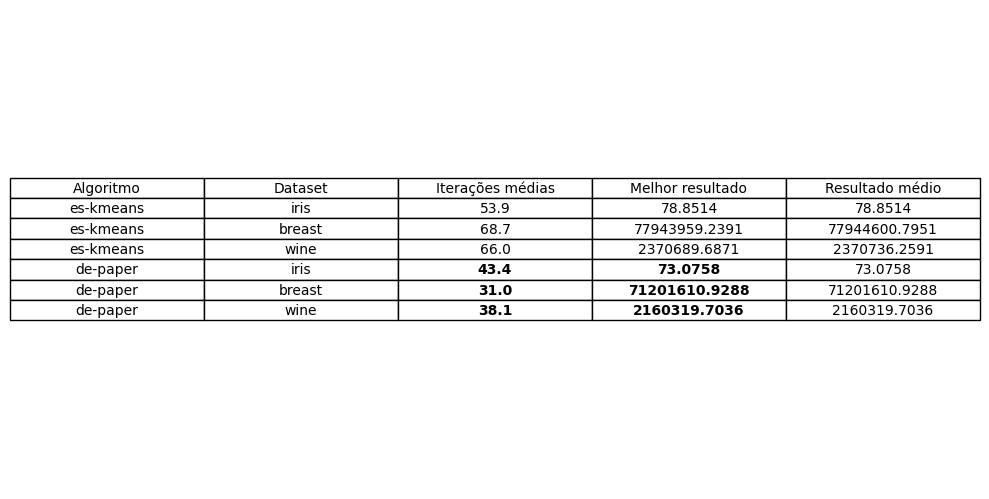

In [42]:
final_fitness_dict = {}
final_fitness_dict["es-kmeans"] = []
final_fitness_dict["de-paper"] = []
termination = DefaultMultiObjectiveTermination(
    period=25, # Sliding Window para a tolerância da fitness como critério de parada
    ftol=0.001,
    n_max_gen=300,
)
seeds = np.random.randint(0, 2**32 - 1, size=7)
for i,seed in enumerate(seeds):
    it_start_time = time()
    print(f"Running Seed {i+1} : {seed}")
    fitness_es_kmeans = ESClusterizationProblems2(seed=seed,es_class=CustomES_Kmeans, termination=termination)
    fitness_de_paper = DEClusterizationProblems2(seed=seed, de_class=DEPaper, termination=termination)

    final_fitness_dict["es-kmeans"].append(fitness_es_kmeans)
    final_fitness_dict["de-paper"].append(fitness_de_paper)
    print(f"Finished Seed {i+1}: {seed}, Runtime : {time()-it_start_time:.2f}s")
plot_results_table2(final_fitness_dict,"final_results.png")

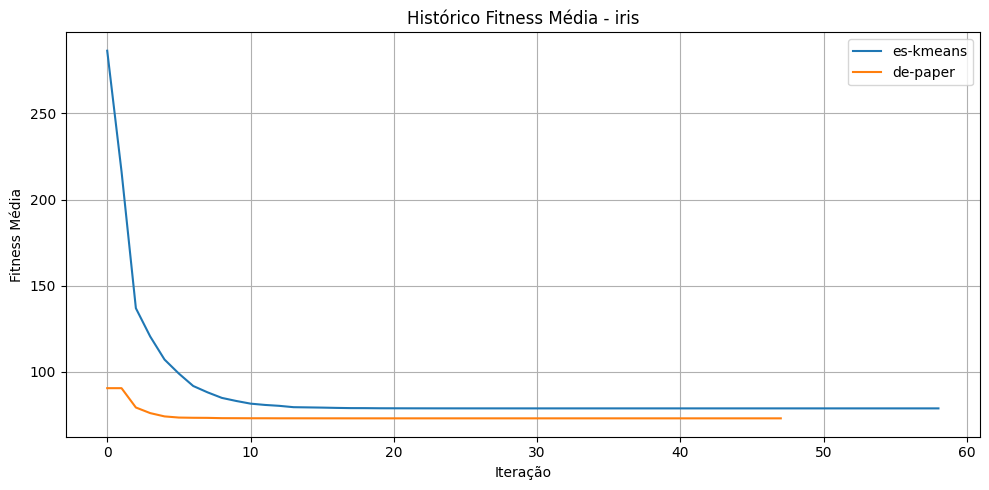

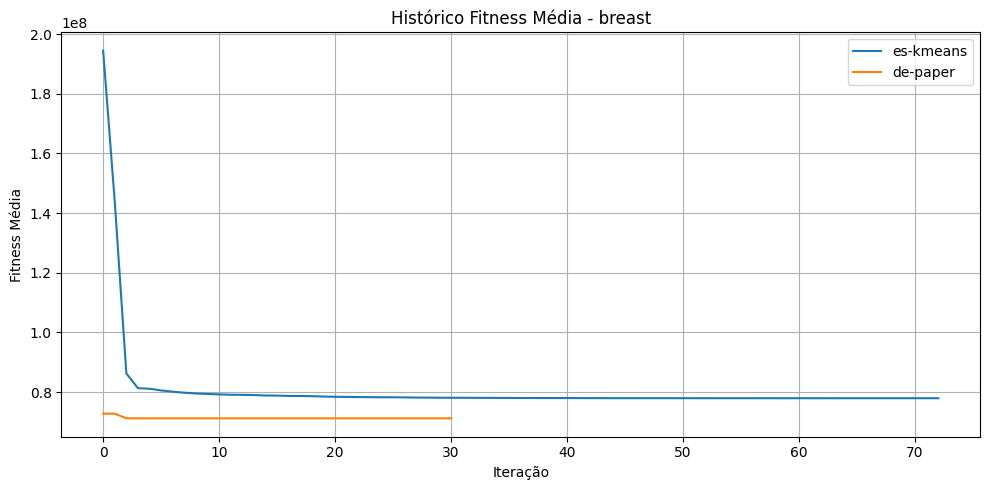

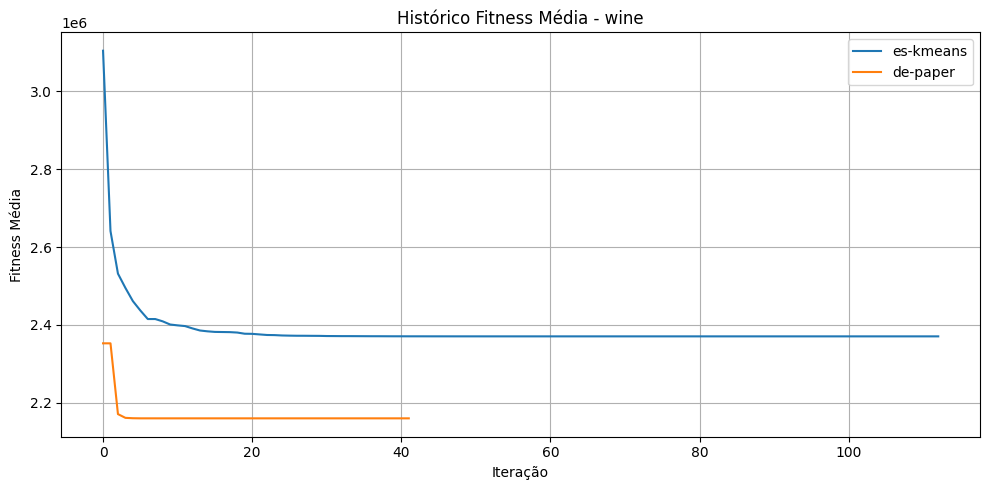

In [43]:
plot_fitness_history(final_fitness_dict, dataset_name='iris',save_path="final_results_iris.png")
plot_fitness_history(final_fitness_dict, dataset_name='breast',save_path="final_results_breast.png")
plot_fitness_history(final_fitness_dict, dataset_name='wine',save_path="final_results_wine.png")

In [44]:
evaluate_test_sets(final_fitness_dict)


=== es-kmeans ===
iris     Média  (SSE) = 5.6706 Melhor (SSE) = 5.6706 Desvio (SSE) = 0.0000
breast   Média  (SSE) = 6725195.4885 Melhor (SSE) = 6725195.4885 Desvio (SSE) = 0.0000
wine     Média  (SSE) = 191502.9417 Melhor (SSE) = 191502.9417 Desvio (SSE) = 0.0000

=== de-paper ===
iris     Média  (SSE) = 5.8635 Melhor (SSE) = 5.8635 Desvio (SSE) = 0.0000
breast   Média  (SSE) = 6759673.7028 Melhor (SSE) = 6759673.7028 Desvio (SSE) = 0.0000
wine     Média  (SSE) = 234536.1378 Melhor (SSE) = 234536.1378 Desvio (SSE) = 0.0000


# Resultado Final

Como demonstrado pela tabela e pelos gráficos acima, o algorítmo do DE converge muito mais rápido que o algorítmo do ES(λ,μ) + KMeans. O ES(λ,μ) + KMeans com novas seeds conseguiu ser competitivo em termos de chegar na mesma fitness que o DE do artigo, porém o DE converge bem mais rápido em média, e isso é possivelmente devido à heurística de KMeans para inicialização, o qual já poẽ o algorítmo do DE em um bom espaço de busca. Para trabalhos futuros, deverá ser realizado uma análise utilizando a mesma heurística de inicialização para o ES(λ,μ) + KMean, já que este somente utiliza uma inicialização randômica.